### Peter Thurner, Jonathan Roth


# Session 1 Project: Epidemic Time Series Analysis + Variant-Aware

---

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](
https://colab.research.google.com/github/ShamsaraE/time-series-medicine-biology-2026/blob/main/notebooks/01_Session_Project_Student.ipynb
)


---


## Learning Goals

In this session you will:

1. Decide whether epidemic dynamics are additive or multiplicative.
2. Understand why `period = 7` is biologically and statistically meaningful.
3. Apply STL decomposition.
4. Interpret trend, seasonal and residual components.
5. Detect anomalies using:
   - Standard Z-score
   - Robust MAD
6. Investigate association of anomalies with:
   - Variants
   - Stringency index
   - Vaccination
7. Detect epidemic peaks using `scipy.signal.find_peaks`.

---


## 1 Import Required Packages

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import STL
from scipy.signal import find_peaks
from scipy.stats import ttest_ind
import statsmodels.formula.api as smf

plt.rcParams["figure.figsize"] = (10,4)
plt.rcParams["axes.grid"] = True


## 2 Load OWID Case Data (Provided)

In [2]:

country = "Germany"
owid_url = "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv"

df = pd.read_csv(owid_url, parse_dates=["date"])

df = df[df["location"] == country][[
    "date",
    "new_cases_smoothed",
    "stringency_index",
    "people_vaccinated_per_hundred"
]].dropna()

df = df[df["date"] >= "2020-03-01"].reset_index(drop=True)



## 3 Why is `period = 7` Appropriate?

### Statistical Reason

COVID reporting follows a weekly cycle:
- Lower reporting during weekends
- Higher reporting mid-week

This creates artificial oscillations every 7 days.

---

### Biological Relevance

Although weekly seasonality mainly reflects reporting,
it also aligns with:

- Human weekly behavior patterns
- Testing availability
- Administrative reporting cycles

Thus, `period = 7` captures systematic short-term structure.

---

### Questions

1. What would happen if we used `period = 30`?
- get a more smooth signal, capturing more long-term structure
- monthly cycle
2. Would STL confuse reporting effects with long-term trend?
- No, because STL preserves short-term structure by only working in a window (if the window is small enough)



## 4 Additive vs Multiplicative Structure

Tasks:

1. Plot raw cases vs date.
2. Plot log(cases) vs date.
3. Decide whether multiplicative structure is appropriate.
- Yes, it is appropriate, since the log transformation yields nice results
- Also, in the first part of the data, small variance around the mean, towards the end, much larger variance around the mean -> multiplicative


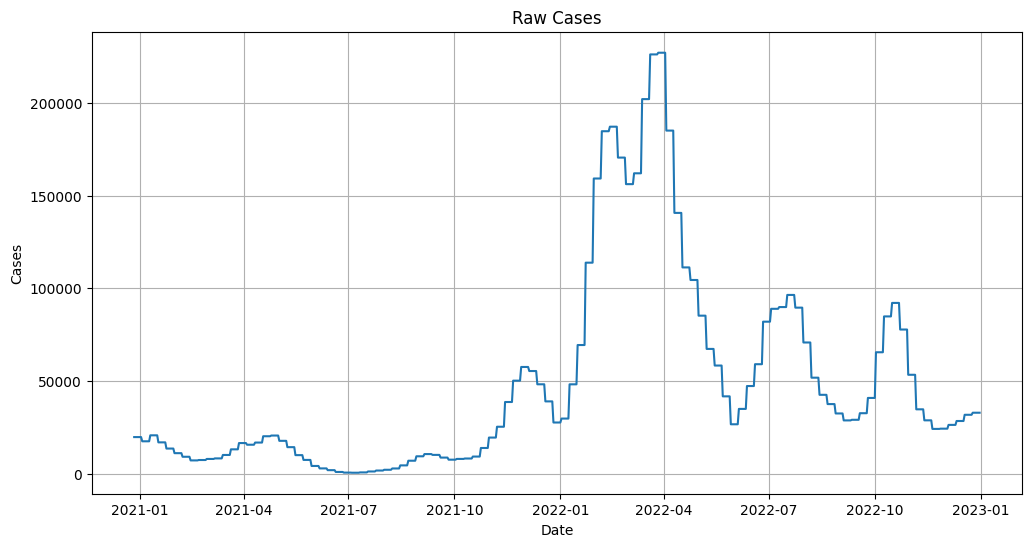

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(df["date"], df["new_cases_smoothed"])
plt.title("Raw Cases")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.show()

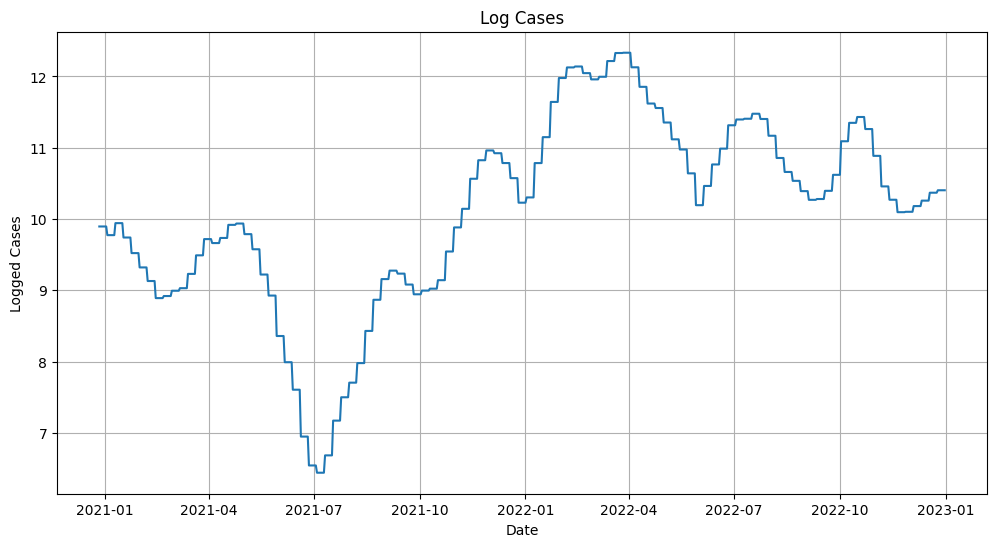

In [9]:
df["log_cases"] = np.log(df["new_cases_smoothed"])

plt.figure(figsize=(12, 6))
plt.plot(df["date"], df["log_cases"])
plt.title("Log Cases")
plt.xlabel("Date")
plt.ylabel("Logged Cases")
plt.show()


## 5 STL Decomposition

Tasks:

1. Apply STL with `period = 7` to log cases.
2. Plot trend, seasonal, and residual components.
3. Interpret:

- Trend → what does it represent epidemiologically? There is no clear trend visible (maybe a slight wave form), but the trend varies around the mean, no real increase/decrease visible
- Seasonal → reporting or biology? Seems like biological, similar pattern occurs over time in a different style
- Residual → what do spikes represent? Maybe some extreme outliers or technical artifacts


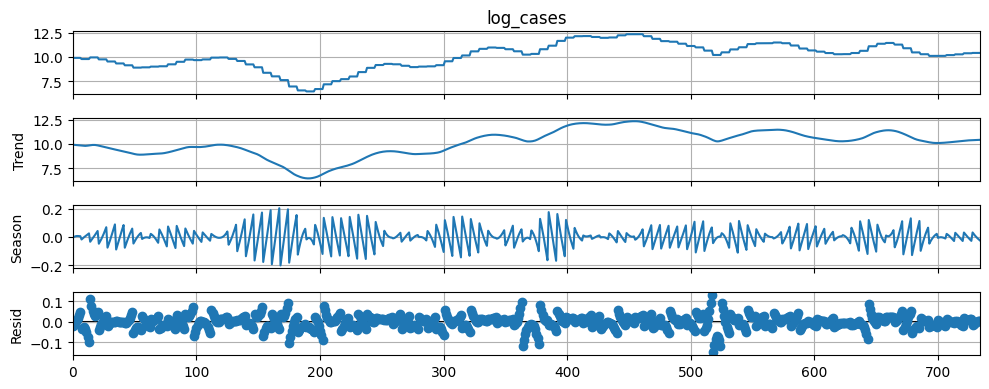

In [11]:
stl = STL(df["log_cases"], period=7)
result_stl = stl.fit()
result_stl.plot()
plt.show()


## 6 Anomaly Detection

We compare two methods.

---

### A) Standard Z-score

Formula:

    z = (residual - mean) / standard_deviation

An anomaly if:

    |z| > 2

Limitation:
Standard deviation is sensitive to extreme values.

---

### B) Robust MAD (Median Absolute Deviation)

Step 1: Compute median of residuals.

Step 2: Compute MAD:

    MAD = median(|residual - median|)

Step 3: Convert to robust z-score:

    robust_z = (residual - median) / (1.4826 × MAD)

Why multiply by 1.4826?
For normally distributed data, this makes MAD comparable to standard deviation.

---

### Why is MAD More Robust?

• Uses median instead of mean  
• Not strongly influenced by extreme spikes  
• Better for heavy-tailed epidemic residuals  

---

### Tasks

1. Implement both methods.
2. Compare number of detected anomalies.
3. Which seems more reasonable?


39


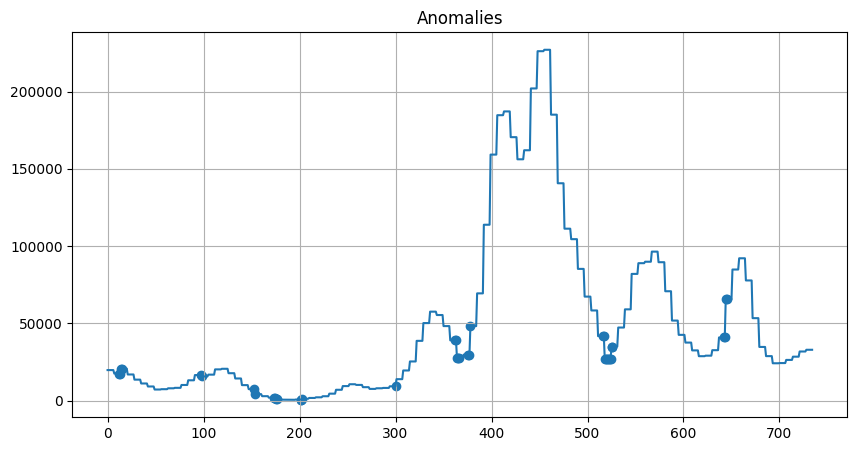

In [24]:
# Standard z-score
z = (result_stl.resid - result_stl.resid.mean()) / result_stl.resid.std()
anomaly_idx_z = np.where(np.abs(z) > 2)[0]
print(len(anomaly_idx_z))

plt.figure(figsize=(10,5))
plt.plot(df["new_cases_smoothed"])
plt.scatter(df["new_cases_smoothed"].index[anomaly_idx_z], df["new_cases_smoothed"].iloc[anomaly_idx_z])
plt.title("Anomalies")
plt.show()


68


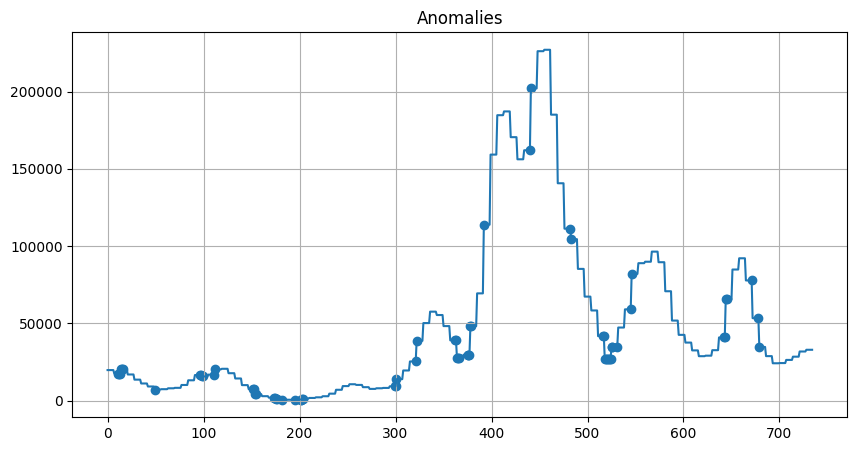

In [69]:
# MAD = median(|residual - median|)
mad = np.median(np.abs(result_stl.resid - result_stl.resid.median()))

# robust_z = (residual - median) / (1.4826 × MAD)
robust_mad = (result_stl.resid - np.median(result_stl.resid.median())) / (1.4826*mad)
anomaly_idx_mad = np.where(np.abs(robust_mad) > 2)[0]


print(len(anomaly_idx_mad))

plt.figure(figsize=(10,5))
plt.plot(df["new_cases_smoothed"])
plt.scatter(df["new_cases_smoothed"].index[anomaly_idx_mad], df["new_cases_smoothed"].iloc[anomaly_idx_mad])
plt.title("Anomalies")
plt.show()


## 7 Integrate ECDC Variant Data

We use weekly variant proportions from ECDC.

Steps:
1. Load weekly variant data.
2. Filter for Germany.
3. Keep only SARS-CoV-2 and proportion indicator.
4. Convert ISO week to date.
5. Identify dominant variant per week.
6. Merge into daily dataset.


In [71]:

variant_url = "https://raw.githubusercontent.com/EU-ECDC/Respiratory_viruses_weekly_data/refs/heads/main/data/variants.csv"

var = pd.read_csv(variant_url)

# Filter Germany + SARS-CoV-2 + proportion + total age
var = var[
    (var["countryname"] == "Germany") &
    (var["pathogen"] == "SARS-CoV-2") &
    (var["indicator"] == "proportion") &
    (var["age"] == "total")
].copy()

# Convert ISO week format (YYYY-Www) to date (Monday of that week)
var["date"] = pd.to_datetime(var["yearweek"] + "-1", format="%G-W%V-%u")

# Identify dominant variant per week
dominant = var.loc[var.groupby("date")["value"].idxmax()]
dominant = dominant[["date", "variant"]]

# Merge into daily dataset
df = df.merge(dominant, on="date", how="left")
df["variant"] = df["variant"].ffill()



### Tasks

1. Plot anomalies on log-case plot and color by variant.
2. Compute anomaly frequency per variant.
3. Are certain variants associated with more residual spikes?


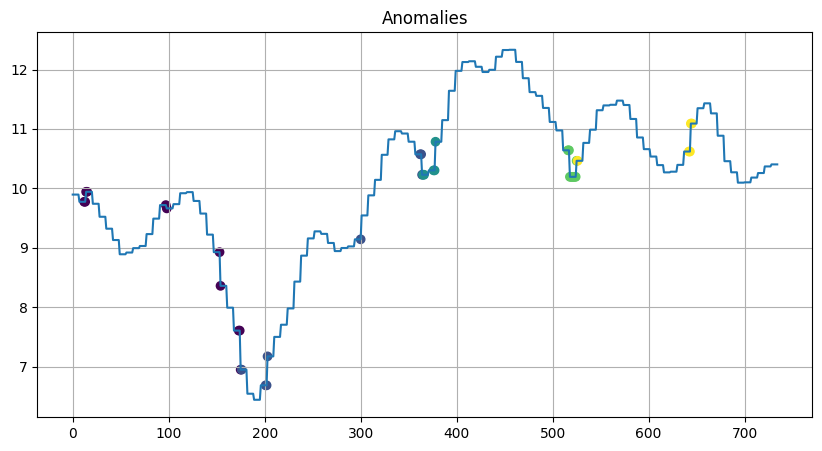

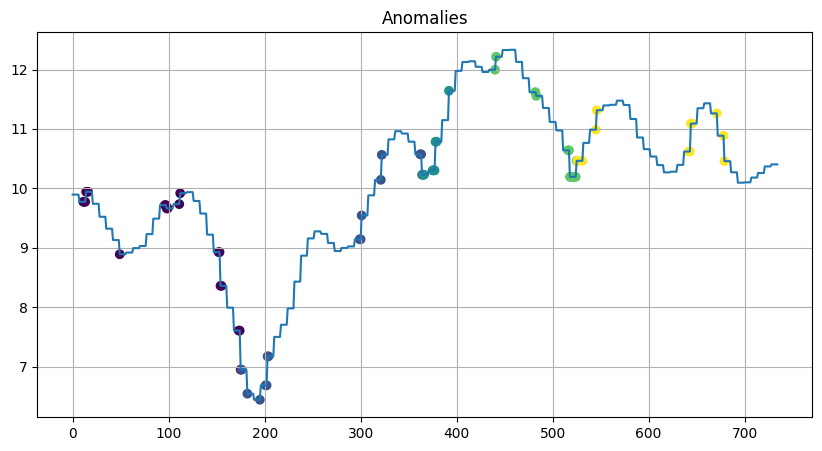

Counts for z: variant
BA.2         10
B.1.617.2     8
BA.1          5
BA.5          5
Name: count, dtype: int64
Counts for mad: variant
B.1.617.2    15
BA.2         14
BA.5         11
BA.1          8
Name: count, dtype: int64
Percentages for z: variant
B.1.617.2    4.232804
BA.1         8.928571
BA.2         9.523810
BA.5         2.392344
Name: count, dtype: float64
Percentages for mad: variant
B.1.617.2     7.936508
BA.1         14.285714
BA.2         13.333333
BA.5          5.263158
Name: count, dtype: float64


In [72]:
labels_z, uniques_z = pd.factorize(df["variant"].iloc[anomaly_idx_z])

plt.figure(figsize=(10,5))
plt.plot(df["log_cases"])
plt.scatter(df["log_cases"].index[anomaly_idx_z], df["log_cases"].iloc[anomaly_idx_z], c=labels_z)
plt.title("Anomalies")
plt.show()

labels_mad, uniques_mad = pd.factorize(df["variant"].iloc[anomaly_idx_mad])

plt.figure(figsize=(10,5))
plt.plot(df["log_cases"])
plt.scatter(df["log_cases"].index[anomaly_idx_mad], df["log_cases"].iloc[anomaly_idx_mad], c=labels_mad)
plt.title("Anomalies")
plt.show()

#######################

counts_z = df["variant"].iloc[anomaly_idx_z].value_counts()
counts_mad = df["variant"].iloc[anomaly_idx_mad].value_counts()
print(f"Counts for z: {counts_z}")
print(f"Counts for mad: {counts_mad}")

#######################

percentage_z = (df["variant"].iloc[anomaly_idx_z].value_counts() / df["variant"].value_counts()) * 100
percentage_mad = (df["variant"].iloc[anomaly_idx_mad].value_counts() / df["variant"].value_counts()) * 100

print(f"Percentages for z: {percentage_z}")
print(f"Percentages for mad: {percentage_mad}")


## 8 Statistical Testing

Perform:

A) Compare stringency during anomaly vs non-anomaly (t-test).

B) Compare vaccination during anomaly vs non-anomaly.

C) Logistic regression:

    is_anomaly ~ stringency + vaccination + variant

Interpret carefully:
Does biological shift (variant) matter more than policy?


In [104]:
#plt.plot(df["stringency_index"])
#plt.plot(df["people_vaccinated_per_hundred"])

# A) Compare stringency during anomaly vs non-anomaly (t-test).
nonanomalies_z = df.drop(df.index[anomaly_idx_z])
stringency_at_anomaly_z = df["stringency_index"].iloc[anomaly_idx_z]
stringency_at_nonanomaly_z = nonanomalies_z["stringency_index"]
t_stat_z, p_value_z = ttest_ind(stringency_at_anomaly_z, stringency_at_nonanomaly_z)
print(f"t_stat_z: {t_stat_z}", f"p_value_z: {p_value_z}")

nonanomalies_mad = df.drop(df.index[anomaly_idx_mad])
stringency_at_anomaly_mad = df["stringency_index"].iloc[anomaly_idx_mad]
stringency_at_nonanomaly_mad = nonanomalies_mad["stringency_index"]
t_stat_mad, p_value_mad = ttest_ind(stringency_at_anomaly_mad, stringency_at_nonanomaly_mad)
print(f"t_stat_mad: {t_stat_mad}", f"p_value_mad: {p_value_mad}")

# B) Compare vaccination during anomaly vs non-anomaly.
vaccination_at_anomaly_z = df["people_vaccinated_per_hundred"].iloc[anomaly_idx_z]
vaccination_at_nonanomaly_z = nonanomalies_z["people_vaccinated_per_hundred"]
vac_t_stat_z, vac_p_value_z = ttest_ind(vaccination_at_anomaly_z, vaccination_at_nonanomaly_z)
print(f"vac_t_stat_z: {vac_t_stat_z}", f"vac_p_value_z: {vac_p_value_z}")

vaccination_at_anomaly_mad = df["people_vaccinated_per_hundred"].iloc[anomaly_idx_mad]
vaccination_at_nonanomaly_mad = nonanomalies_mad["people_vaccinated_per_hundred"]
vac_t_stat_mad, vac_p_value_mad = ttest_ind(vaccination_at_anomaly_mad, vaccination_at_nonanomaly_mad)
print(f"vac_t_stat_z: {vac_t_stat_z}", f"vac_p_value_z: {vac_p_value_z}")

# C) Logistic regression: is_anomaly ~ stringency + vaccination + variant
df["is_anomaly"] = 0
df.loc[anomaly_idx_z, "is_anomaly"] = 1

model = smf.ols(formula="is_anomaly ~ stringency_index + people_vaccinated_per_hundred + variant", data=df)

fit = model.fit()
print(fit.summary())

t_stat_z: 0.7500956131452117 p_value_z: 0.453437811204088
t_stat_mad: 1.346692978559652 p_value_mad: 0.17849536995562296
vac_t_stat_z: -0.08601773573145127 vac_p_value_z: 0.9314758084800356
vac_t_stat_z: -0.08601773573145127 vac_p_value_z: 0.9314758084800356
                            OLS Regression Results                            
Dep. Variable:             is_anomaly   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     2.262
Date:                Mon, 23 Feb 2026   Prob (F-statistic):             0.0471
Time:                        14:32:35   Log-Likelihood:                 63.641
No. Observations:                 559   AIC:                            -115.3
Df Residuals:                     553   BIC:                            -89.33
Df Model:                           5                                         
Covariance Type:            no


## 9 Peak Detection Using `find_peaks`

Function: `scipy.signal.find_peaks`

It detects local maxima.

Parameter:

    distance = 60

What does it control?

• Minimum number of days between detected peaks  
• Prevents detecting small fluctuations as new waves  
• Roughly ensures waves are at least ~2 months apart  

---

### Tasks

1. Detect peaks with distance=60.
2. Plot peaks on raw case data.
3. Compare with STL trend waves.




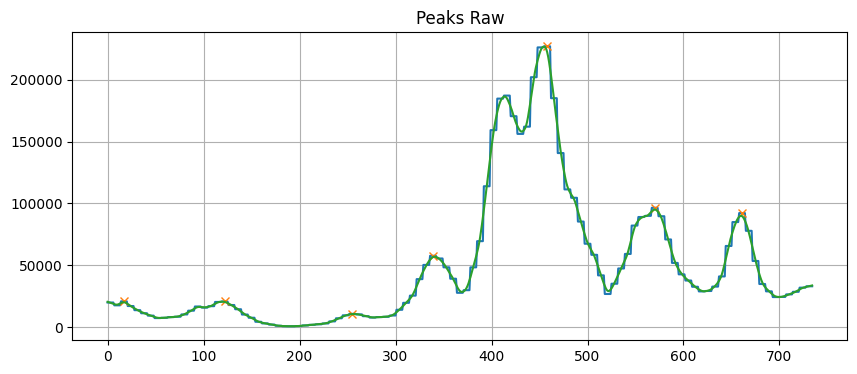

In [100]:
stl_raw = STL(df["new_cases_smoothed"], period=7)
result_stl_raw = stl_raw.fit()
peaks_raw, _ = find_peaks(df["new_cases_smoothed"], distance = 60)

plt.plot(df["new_cases_smoothed"])
plt.plot(peaks_raw, df["new_cases_smoothed"][peaks_raw], "x")
plt.title("Peaks Raw")
plt.plot(result_stl_raw.trend)

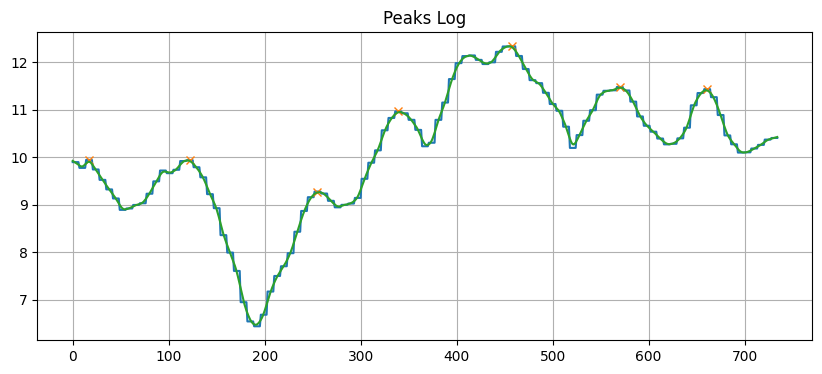

In [101]:
peaks_log, _ = find_peaks(df["log_cases"], distance = 60)

plt.plot(df["log_cases"])
plt.plot(peaks_log, df["log_cases"][peaks_log], "x")
plt.title("Peaks Log")
plt.plot(result_stl.trend)